# GP scorer

This notebook is used to run GP in several configurations, showing its score in the reconstruction of a given function

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from GaussianProcess.engine import GPCalculator
from GaussianProcess.diagnostics import GPScorer
from parametric_approach.polynomial import PolynomialFit

from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from itertools import product

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

## Settings

In [2]:
data_range  = [0.,2.]
recon_range = [0.1,1.8]

order = 1
fiducial = {'a0': 3,
            'a1': -1,
            #'a2': 5,
            #'a3': -0.1
           }

free_settings = {'Nrecon': [5,7,10,12,15],
                 #'order': [3,4,5],
                 'Ndata': [25,50,75,100],
                 'error': [1,5,10.],
                 'kernel': ['RBF'],
                 'method': ['MAP']}

prior_sampling = 1

## Functions

In [3]:
def get_theory(params,order):


    theory = PolynomialFit(None,None,order=order)
    theory_model = lambda x: theory.generate(x,[float(par) for par in params.values()])

    return theory_model

def create_data(theory_model,Ndata,err_fac):

    dataset = pd.DataFrame({'x': np.random.uniform(data_range[0],data_range[1],Ndata)})
    
    thvals = theory_model(dataset['x'])['f']
    errors = abs(thvals)*err_fac/100
    dataset['f'] = thvals#np.random.normal(thvals,errors)
    dataset['f_err'] = errors
    
    covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
    covmat.index = covmat.columns

    return dataset,covmat

def get_GP(dataset,covmat,kernel,x_recon,method):

    gp = GPCalculator(dataset,covmat,kernel_type=kernel,chatty=False)

    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method)

    return means,joint_cov,lml

## Run grid

In [7]:
import math
dfs = []

keys = free_settings.keys()

locind = 0
total  = math.prod(len(v) for v in free_settings.values())*prior_sampling
for values in product(*free_settings.values()):

    print('')
    loc_dict = dict(zip(keys, values))
    loc_dict['order'] = order

    x_recon = np.linspace(recon_range[0],recon_range[1],loc_dict['Nrecon'])

    for Nint in range(prior_sampling):

        tini = time()

        df = pd.DataFrame(loc_dict,index=[0])
        df['Iteration'] = Nint+1
        
        #params = {'a{}'.format(ind): np.random.uniform(-5.,5) for ind in range(loc_dict['order']+1)}
        params = deepcopy(fiducial)
        

        theory = get_theory(params,loc_dict['order'])

        dataset,covmat = create_data(theory,loc_dict['Ndata'],loc_dict['error'])

        means,joint_cov,lml = get_GP(dataset,covmat,loc_dict['kernel'],x_recon,loc_dict['method'])

        scorer = GPScorer(means,joint_cov,chatty=False)

        theory_df = pd.DataFrame({'x': x_recon}|{func: theory(x_recon)[func] for func in ['f','d1','d2','int']})
        res         = scorer.score_against_theory(theory_df)

        df['Mahalanobis score'] = res['red_chi2']

        res = scorer.score_pointwise(theory_df)

        df['Diagonal score'] = res['red_chi2']

        datasets = [{'type': 'f',
                     'df': dataset,
                     'cov': covmat}]

        res = scorer.score_against_data(datasets)

        df['Data score'] = res['red_chi2']

        dfs.append(df)
        
        print('Test {} of {} done in {:.2f} s'.format(locind,total,time()-tini))

        locind += 1

results = pd.concat(dfs,ignore_index=True)


Test 0 of 60 done in 3.89 s

Test 1 of 60 done in 1.78 s

Test 2 of 60 done in 2.04 s

Test 3 of 60 done in 4.90 s

Test 4 of 60 done in 1.95 s

Test 5 of 60 done in 1.91 s

Test 6 of 60 done in 3.98 s

Test 7 of 60 done in 1.81 s

Test 8 of 60 done in 1.92 s

Test 9 of 60 done in 4.14 s

Test 10 of 60 done in 1.49 s

Test 11 of 60 done in 1.38 s

Test 12 of 60 done in 10.29 s

Test 13 of 60 done in 1.56 s

Test 14 of 60 done in 1.39 s

Test 15 of 60 done in 2.87 s

Test 16 of 60 done in 1.43 s

Test 17 of 60 done in 1.33 s

Test 18 of 60 done in 2.99 s

Test 19 of 60 done in 1.54 s

Test 20 of 60 done in 1.46 s

Test 21 of 60 done in 2.91 s

Test 22 of 60 done in 1.56 s

Test 23 of 60 done in 1.44 s

Test 24 of 60 done in 9.01 s

Test 25 of 60 done in 1.87 s

Test 26 of 60 done in 2.28 s

Test 27 of 60 done in 6.31 s

Test 28 of 60 done in 3.05 s

Test 29 of 60 done in 3.14 s

Test 30 of 60 done in 5.49 s

Test 31 of 60 done in 3.31 s

Test 32 of 60 done in 3.11 s

Test 33 of 60 done

In [8]:
results

,Nrecon,Ndata,error,kernel,method,order,Iteration,Mahalanobis score,Diagonal score,Data score
0,5,25,1.0,RBF,MAP,1,1,0.366452,0.148611,0.200088
1,5,25,5.0,RBF,MAP,1,1,0.474811,0.309482,0.070692
2,5,25,10.0,RBF,MAP,1,1,0.484798,0.370784,0.048244
3,5,50,1.0,RBF,MAP,1,1,0.385244,0.143622,0.323481
4,5,50,5.0,RBF,MAP,1,1,0.421631,0.223982,0.059594
5,5,50,10.0,RBF,MAP,1,1,0.441125,0.219422,0.040910
6,5,75,1.0,RBF,MAP,1,1,0.388805,0.118113,0.401361
7,5,75,5.0,RBF,MAP,1,1,0.378426,0.181292,0.085894
8,5,75,10.0,RBF,MAP,1,1,0.440804,0.240026,0.035334
9,5,100,1.0,RBF,MAP,1,1,0.398783,0.131962,0.371147


In [10]:
import plotly.express as px # Plotly is better for interactive Parallel Coordinates

# Assuming 'df' is your results dataframe
# 1. Normalize the Score to a 0-1 range for better coloring
#df['Score_Norm'] = (df['Score'] - df['Score'].min()) / (df['Score'].max() - df['Score'].min())

# 2. Create an interactive plot
fig = px.parallel_coordinates(results, 
    dimensions=['Nrecon', 'Ndata', 'error'],#, 'order', 'Iteration'],
    color="Data score",
    color_continuous_scale=px.colors.sequential.Viridis_r, # _r so low is yellow/distinct
    title="Reconstruction Performance Grid")
plt.show()

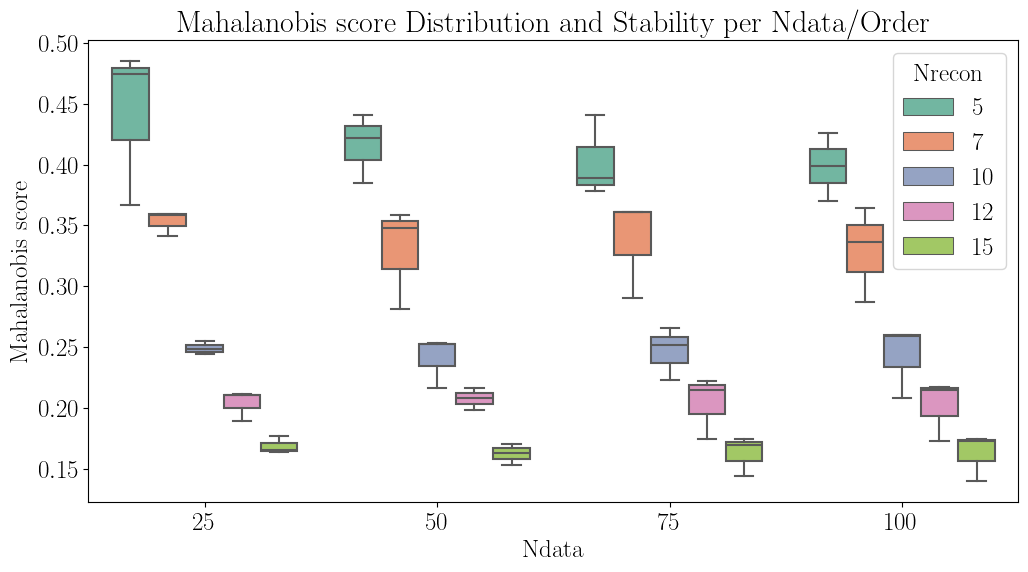

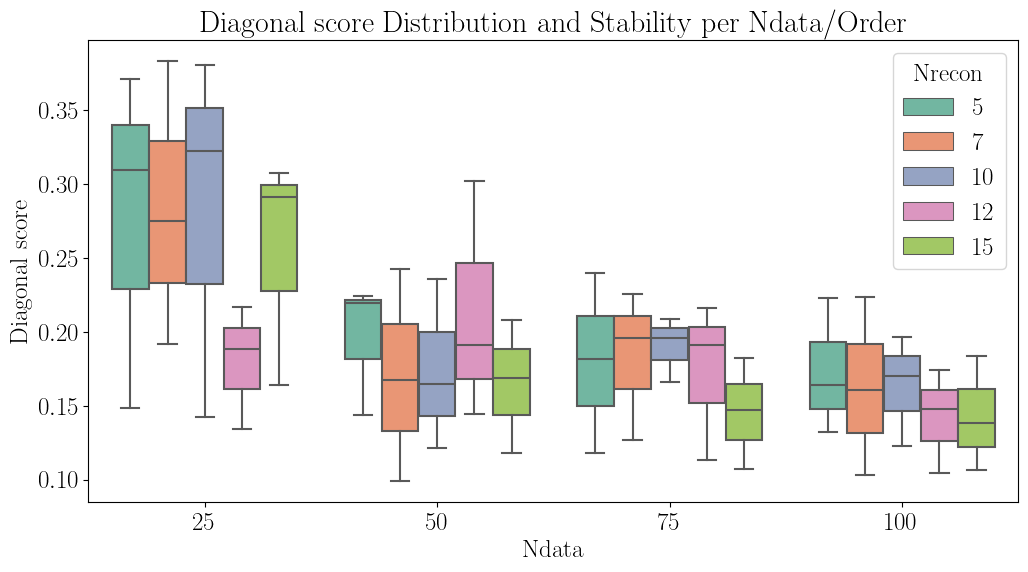

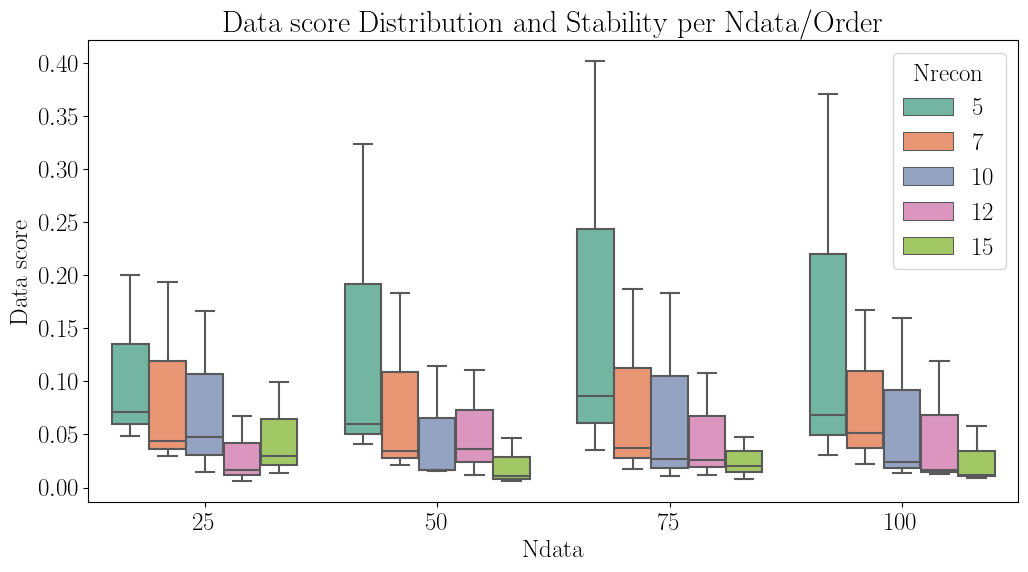

In [16]:
for score in ['Mahalanobis','Diagonal','Data']:
    plt.figure(figsize=(12, 6))
    sb.boxplot(data=results, x='Ndata', y='{} score'.format(score), hue='Nrecon', palette='Set2')
    plt.title("{} score Distribution and Stability per Ndata/Order".format(score));

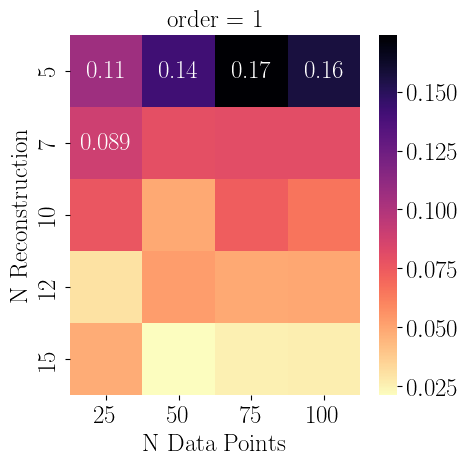

In [13]:
df_mean = results.groupby(['Nrecon', 'Ndata', 'order'])['Data score'].mean().reset_index()

# Create a grid where each 'order' gets its own heatmap
g = sb.FacetGrid(df_mean, col="order", height=5)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index='Nrecon', columns='Ndata', values='Data score')
    sb.heatmap(d, annot=True, cmap='magma_r', **kwargs)

g.map_dataframe(draw_heatmap)
g.set_axis_labels("N Data Points", "N Reconstruction");